In [ ]:
# ------------------------------
#        Milestone 1
# ------------------------------


In [4]:
#imported libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

#dataset loading 
df = pd.read_csv("../data/gold_historical_data.csv")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995


In [14]:
#info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2510 non-null   datetime64[ns]
 1   Adj Close  2510 non-null   float64       
 2   Close      2510 non-null   float64       
 3   High       2510 non-null   float64       
 4   Low        2510 non-null   float64       
 5   Open       2510 non-null   float64       
 6   Volume     2510 non-null   int64         
 7   Month      2510 non-null   int32         
 8   Day        2510 non-null   int32         
 9   Weekday    2510 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(1)
memory usage: 166.8 KB


In [15]:
#stats
df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,Month,Day,Weekday
count,2510,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000
mean,2021-02-02 12:33:50.916334592,1862.680556,1862.680556,1872.036176,1852.944064,1862.260478,5161.460558,6.547410,15.749801,2.028287
min,2016-02-05 00:00:00,1127.800049,1127.800049,1132.800049,1123.900024,1126.900024,0.000000,1.000000,1.000000,0.000000
25%,2018-08-07 06:00:00,1306.224976,1306.224976,1310.325043,1301.624969,1306.224976,53.250000,4.000000,8.000000,1.000000
50%,2021-02-03 12:00:00,1767.350037,1767.350037,1777.200012,1759.900024,1768.049988,213.000000,7.000000,16.000000,2.000000
75%,2023-08-02 18:00:00,1968.975006,1968.975006,1978.375031,1960.599976,1969.325012,655.500000,10.000000,23.000000,3.000000
max,2026-01-30 00:00:00,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000,12.000000,31.000000,4.000000
std,NaN,713.045002,713.045002,719.366255,706.561716,712.946710,28443.386437,3.424402,8.754999,1.399338


In [16]:
#missing value check
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Month        0
Day          0
Weekday      0
dtype: int64

In [17]:
#date column coversion
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
#added year feature to see in which year price was up
df['Year'] = df['Date'].dt.year
df.columns
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Month,Day,Weekday,Year
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2,5,4,2016
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2,8,0,2016
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2,9,1,2016
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2,10,2,2016
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2,11,3,2016


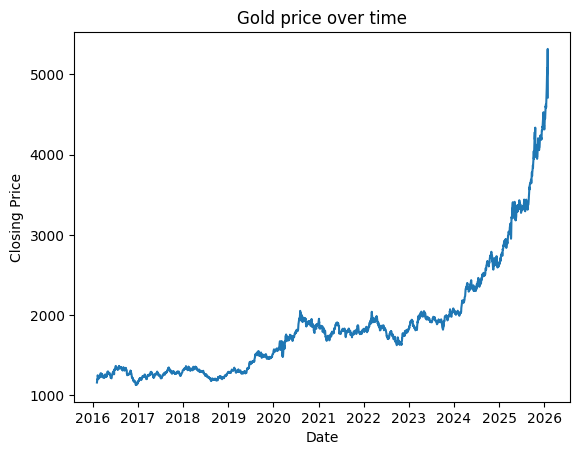

In [42]:
#gold price over time - Visualization 1

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.Figure(figsize=(15,10))
plt.title("Gold price over time")
plt.plot(df['Date'], df['Close'])
plt.show()


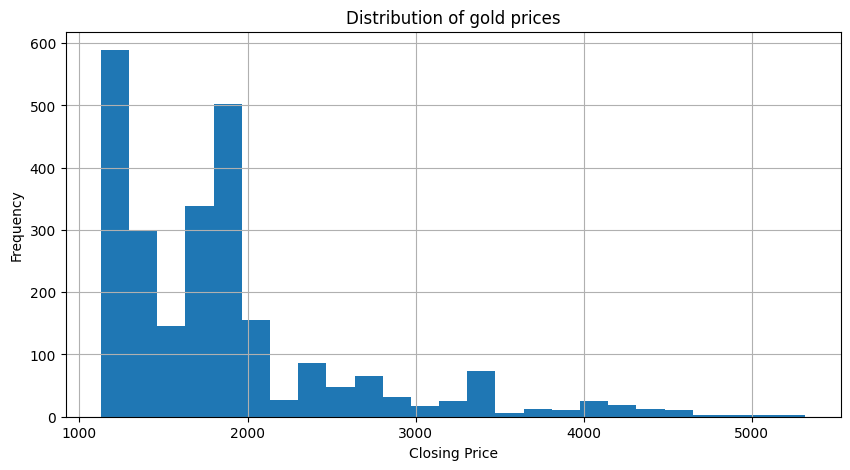

In [21]:
#price distribution - histogram - 2
plt.figure(figsize=(10,5))
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Distribution of gold prices")
df['Close'].hist(bins=25)
plt.show()

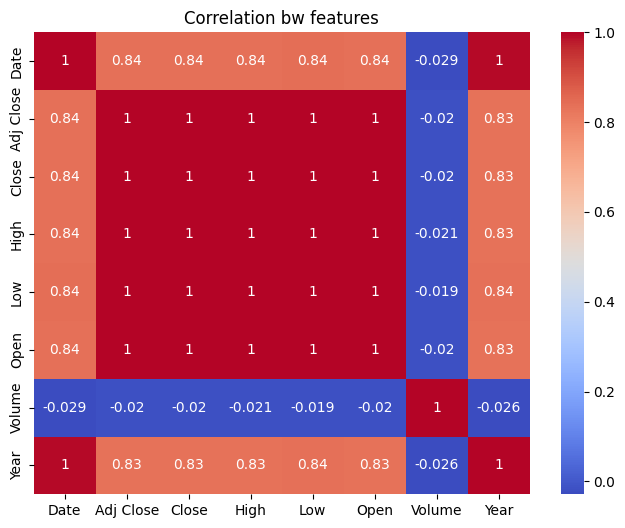

In [45]:
#correlation heatmap - 3
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation bw features")
plt.show()

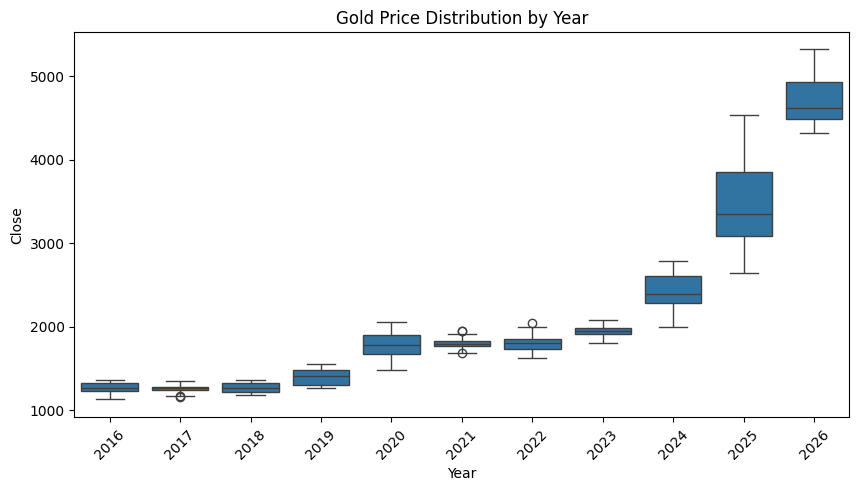

In [24]:
#closing price per year - boxplot- 4

plt.figure(figsize=(10,5))
plt.title("Gold Price Distribution by Year")
sns.boxplot(x='Year', y='Close', data=df)
plt.xticks(rotation=45)
plt.show()


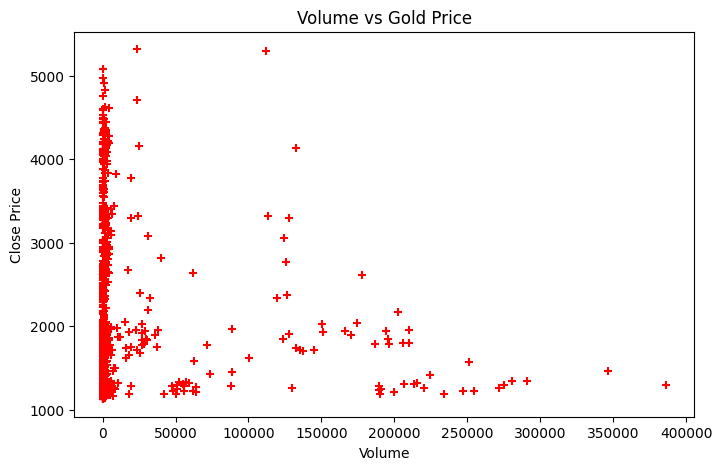

In [25]:
#to see relationship bw trading volume and closing price - scatter plot -5
plt.figure(figsize=(8,5))
plt.scatter(df['Volume'], df['Close'], color = 'red', marker='+')
plt.title("Volume vs Gold Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

In [13]:
# ------------------------------
#         Milestone 2
# ------------------------------


In [26]:
# check missing values
df.isnull().sum()


Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Month        0
Day          0
Weekday      0
Year         0
dtype: int64

In [27]:
df.columns 
# Encoding categorical variables
# The dataset does not contain categorical variables,
# so this step is not required.

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Month',
       'Day', 'Weekday', 'Year'],
      dtype='object')

In [28]:
# Feature Eng - Extracting  month, day and weekday from date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

df.head()


,Date,Adj Close,Close,High,Low,Open,Volume,Month,Day,Weekday,Year
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2,5,4,2016
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2,8,0,2016
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2,9,1,2016
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2,10,2,2016
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2,11,3,2016


In [30]:
X = df[['Open','High','Low','Volume','Year','Month','Day','Weekday']]
y = df['Close']

In [32]:
#Scaling features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


In [33]:
from sklearn.model_selection import train_test_split

# train and temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# validation and test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (1757, 8)
Validation size: (376, 8)
Test size: (377, 8)


In [ ]:
# ------------------------------
#        Milestone 3
# ------------------------------

In [34]:
# model created
model = linear_model.LinearRegression()

# training model 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = model.predict(X_test)

In [37]:
#Baseline Metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MSE: 90.1433970531925
RMSE: 9.494387660781104
MAE: 4.250274670097258


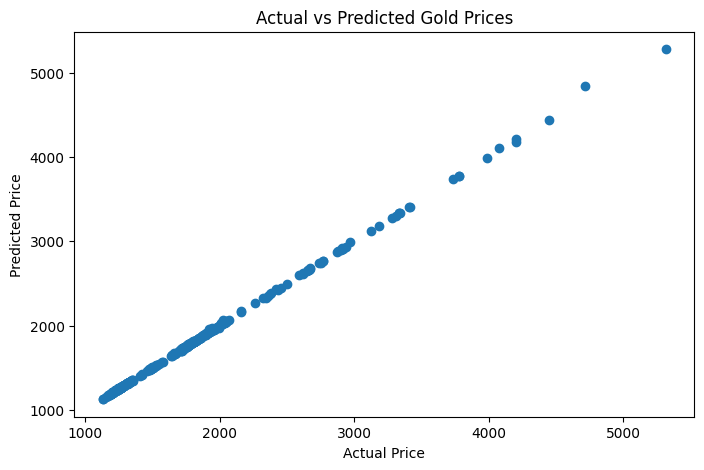

In [39]:
#Plotting to see Actual vs Predicted Prices

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Gold Prices")
plt.show()
